# Travaux dirigés 3 - MAP201, thème équation différentielles

Le TP est à faire en python, où la réponse à chaque question est dans une cellule séparée. On veillera à écrire un code suffisamment clair pour être éventuellement réutilisé d'un exercice à l'autre. 

In [11]:
!jupyter nbconvert --to html TP_MAP201_2025_3.ipynb

[NbConvertApp] Converting notebook TP_MAP201_2025_3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 559112 bytes to TP_MAP201_2025_3.html


In [2]:
import numpy as np #importe les outils de gestion des tableaux
import matplotlib.pyplot as plt #importe les outils d'affichages matplotlib
plt.rcParams['figure.dpi'] = 120 #reglage facultatif de résolution des figures
plt.rcParams['savefig.dpi'] = 240 #reglage facultatif de résolution des figures enregistrées

## Exercice 1 - Modèle d'épidémie.

On considère une population de $S$ individus sains où l'on introduit à l'instant $t=0$, une population de $m$ individus malades. On suit ensuite l'évolution de l'épidémie en divisant la population en trois parties distinctes:

- $x(t)$: la population d'individus sains, qui vérifie $x(0)=S$ $(>0)$.
- $y(t)$: la population d'individus malades, qui vérifie $y(0)=m$ $(>0)$.
- $z(t)$: la population d'individus qui sont guéris et immunisés de la maladie. A l'instant $t=0$ on a $z(0)=0$.

On suppose que $x(t),y(t),z(t)$ suivent une évolution du type
$$\begin{cases}
\dot{x}(t)=-k\frac{y(t)}{x(t)+y(t)+z(t)}x(t) & (1)\\
\dot{y}(t)=k\frac{y(t)}{x(t)+y(t)+z(t)}x(t)-\ell y(t) & (2)\\
\dot{z}(t)= \ell y(t) & (3)
\end{cases}$$
où $k,\ell>0$ sont des paramètres de la maladie.

### 1)

Donner une interprétation de chaque terme du modèle. Que peuvent représenter les quantités $k,\ell $ ?

Réponse: 

### 2)
Grâce à une méthode d'Euler, calculer les solutions et tracer le graphe de $x(t),y(t),z(t)$ en fonction de $t$, pour les paramètres suivants:

$$S=100, m=1,k=6, \ell=3$$

On utilisera un nombre de pas $N$ suffisamment grand. On pensera a bien annoter chaque courbe, et à afficher le graphe sur un temps suffisamment grand pour observer toute l'évolution de $x,y,z$. Par lecture graphique, quel est le sens de variation et le comportement asymptotique de $x(t),y(t),z(t)$ ? On pourra aussi calculer leur valeur limites et extrémales.

In [3]:
#Réponse:

### 3)
Quels changements observe-t-on si on change $m=1$ en $m=0.1$, $m=0.01$ ? Comment change le tableau de variations des solutions ?

In [4]:
#Réponse:

### 4)

On étudie maintenant le changement de comportement de la maladie selon les paramètres $k,\ell$. On fixe
$$S=100,m=0.1,\ell=4$$
et on va faire varier $k$ sur une subdivision de l'intervalle $[0,10]$. On note $z_{lim}(k)$ la limite de $z(t)$, lorsque $x(t),y(t),z(t)$ est la solution associée au paramètre $k$.

Ecrire une fonction qui renvoie une approximation de $z_{lim}(k)$, et afficher le graphe de $z_{lim}(k)$ en fonction de $k$ pour $k\in [0,10]$. Que peut-on conjecturer ?

In [5]:
#Réponse:


### Exercice 2

On introduit ici une nouvelle méthode permettant d'approcher numériquement la solution d'une équation du type
$$\begin{cases}
\dot{x}(t)=f(t,x(t))\\
x(0)=x_{in}
\end{cases}$$

## 1)
Écrire une fonction qui prend en entrée:

- Une fonction $f:\begin{cases} \R\times \R\to\R\\ (t,x)\mapsto f(t,x)\end{cases}$.
- Une condition initiale $x_{in}\in\R$.
- Un temps final $T_f$.
- Un nombre de pas $N\in\mathbb{N}^*$.

et qui renvoie les tableaux $T=[t_0,t_1,...,t_N]$ et $X=[x_0,...,x_N]$ où on a toujours $t_i=\frac{i T_f}{N}=i\ \Delta t$, et la suite $(x_i)_{0\leq i\leq N}$ est obtenue par récurrence de la manière suivante:
$$\begin{cases}
x_0=x_{in}\\
x_{i+1}=x_i+\Delta t\ f\left(t_i,x_i\right),\ \forall i=0,1,...,N-1
\end{cases}$$
Quel schéma numérique reconnaissez-vous ?


In [3]:
#Réponse:
def shema1(f, xin, Tfin, N):
    T = np.linspace(0, Tfin, N + 1)
    X = np.zeros(N+1)

    dt = Tfin / N
    X[0] = xin

    for i in range(N):
        X[i+1]=X[i]+ dt* f(T[i], X[i])

    return T, X



## 2)
Faire de même, mais cette fois pour ce nouveau schéma : la suite $(x_i)_{0\leq i\leq N}$ est obtenue par récurrence de la manière suivante:
$$\begin{cases}
x_0=x_{in}\\
x_{i+1}=x_i+\frac{\Delta t}{2} \ \left[f(t_i,x_i) +f\left(t_{i+1},x_i+\Delta t f(t_i,x_i) \right)]\right),\ \forall i=0,1,...,N-1
\end{cases}$$


In [4]:
#Réponse:
def shema2(f, xin, Tfin, N):
    T = np.linspace(0, Tfin, N + 1)
    X = np.zeros(N+1)

    dt = Tfin / N
    X[0] = xin

    for i in range(N):
        X[i+1] = X[i] + (dt/2) * (f(T[i], X[i]) + f(T[i+1], X[i] + dt * f(T[i], X[i])))

    return T, X


## 3)
On considère l'équation différentielle
$$
\begin{cases}
\dot{x}(t)=-\sin(t)-x(t)\\
x(0)=1
\end{cases}
$$
Montrer que la solution à cette équation est
$$x(t)=\frac{3}{2}e^{-t}+\frac{\cos(t)-\sin(t)}{2}$$

Réponse:
- la solution à cette équation est
$$x(t)=\frac{1}{2}e^{-t}+\frac{\cos(t)-\sin(t)}{2}$$

## 4)

Ecrire une fonction $\tt{erreur1}$ prenant en argument un entier $N$, et calculant l'erreur commise par le schéma $1$, c'est-à-dire

$$\log_{10}\max_{i=0,1,...,N}|x(t_i)-x_i^{1}| $$

où $(x_i^{1})_{i=0,..,N}$  est la solution construite par la première méthode avec un temps final $T_f=20$.


In [5]:
#Réponse:
def f(t, x):
    return  (- np.sin(t) - x )

def x_exact(t):
    return (0.5 * np.exp(-t) + (0.5 * (np.cos(t) - np.sin(t))))

def erreur1(N):
    t, x_app = shema1(f, 1, 20, N)
    x_ex = x_exact(t)
    return np.max(np.abs(x_ex - x_app))

## 5)

Ecrire une fonction $\tt{erreur2}$ prenant en argument un entier $N$, et calculant l'erreur commise par le schéma $2$, c'est-à-dire

$$\max_{i=0,1,...,N}|x(t_i)-x_i^{2}|$$

où $(x_i^{2})_{i=0,..,N}$  est la solution construite par la deuxième méthode avec un temps final $T_f=20$.


In [6]:
#Réponse:

def erreur2(N):
    t, x_app = shema2(f, 1, 20, N)
    x_ex = x_exact(t)
    return np.max(np.abs(x_ex - x_app))


## 6)
Tracer, en échelle logarithmique, l'erreur commise par chacune des méthodes d'approximation en fonction de $N\in \{2^0,2^1,2^2,2^3,..,2^{20}\}$. On tracera donc le graphe de

$$\log_{10}\left(\tt{erreur1}(N)\right) \text{ et }\log_{10}\left(\tt{erreur2}(N)\right) $$

en fonction de $\log_{10}(N)$. Qu'observe-t-on ?

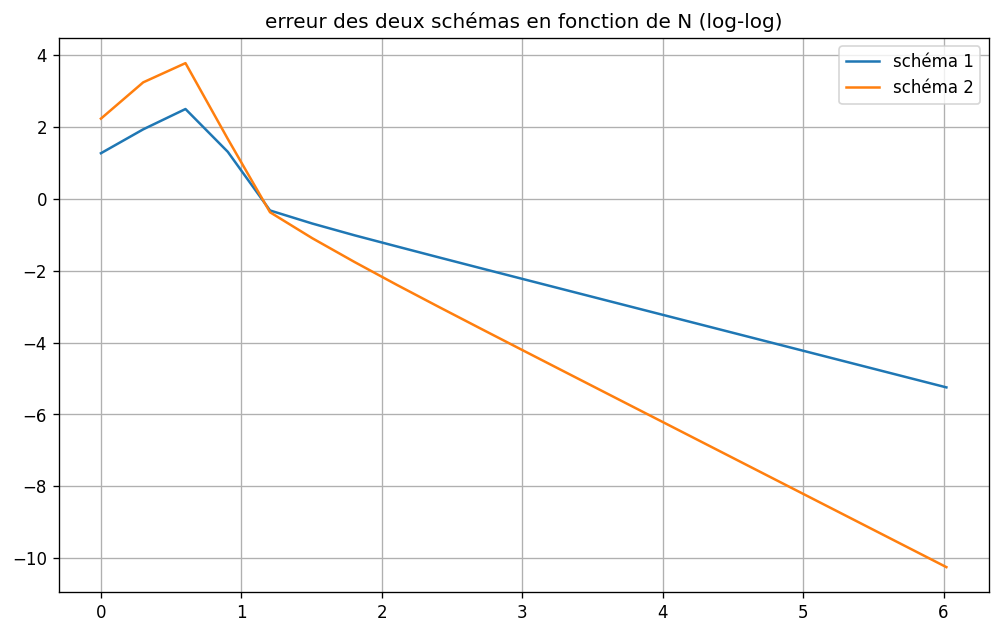

In [7]:
#Réponse:
N = [2**k for k in range(21)]
log_N = np.log10(N)
log_err1 = [np.log10(erreur1(i)) for i in N]
log_err2 = [np.log10(erreur2(j)) for j in N]

plt.figure(figsize=(10, 6))
plt.plot(log_N, log_err1, label="schéma 1")
plt.plot(log_N, log_err2, label="schéma 2")
plt.title("erreur des deux schémas en fonction de N (log-log)")
plt.grid(True)
plt.legend()
plt.show()



## 7)
On dit qu'une méthode d'approximation est d'ordre au moins $k$ s'il existe une constante $C>0$ indépendante de $N$ telle que, en notant $(x_{i})_{i=0,2,..,N}$ l'approximation obtenue, alors
$$\max_{i=0,1,...,N}|x(t_i)-x_i^{euler}|\leq \frac{C}{N^k}$$

Si de plus $k$ est la valeur maximale pour laquelle cette condition est vérifiée, on dit que la méthode est exactement d'ordre $k$. 

Comment lire l'ordre de l'erreur dans le graphe ci-dessus ? En utilisant la figure et les données obtenues dans la question précédente, estimer l'ordre de chaque méthode.

Réponse:
-  l’ordre k c'est l’opposé de la pente de la courbe dans le graphe log-log, plus la pente est raide (vers le bas), plus k est grand, méthode est plus précise
- methode 1 est d’ordre 1 (a = -1 donc k = 1)
- methode 2 est d’ordre 2 (a = -2 donc k = 2)

Ordre de la shema 1: 1.01
Ordre de la shema 2 : 2.03


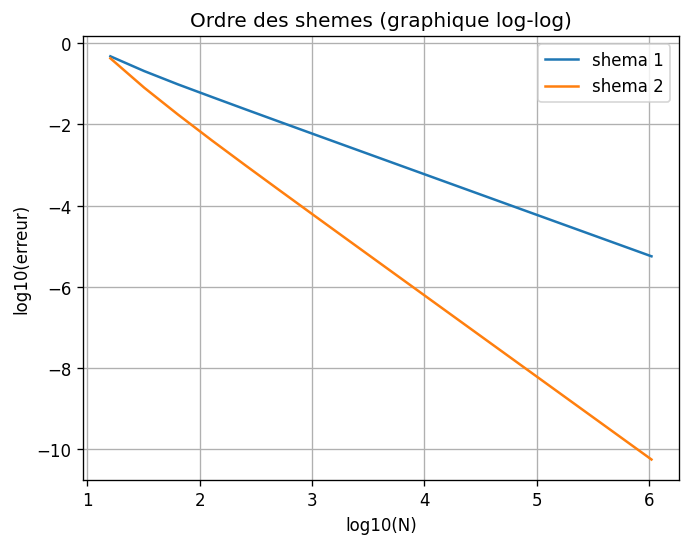

In [8]:
#Réponse:

N = [2**k for k in range(4, 21)]
log_N = np.log10(N)
log_err1 = [np.log10(erreur1(n)) for n in N]
log_err2 = [np.log10(erreur2(n)) for n in N]

coeffs1 = np.polyfit(log_N, log_err1, 1)
coeffs2 = np.polyfit(log_N, log_err2, 1)

print(f"Ordre de la shema 1: {-coeffs1[0]:.2f}")
print(f"Ordre de la shema 2 : {-coeffs2[0]:.2f}")

plt.plot(log_N, log_err1, label='shema 1')
plt.plot(log_N, log_err2, label='shema 2')
plt.xlabel('log10(N)')
plt.ylabel('log10(erreur)')
plt.legend()
plt.grid(True)
plt.title("Ordre des shemes (graphique log-log)")
plt.show()


### Exercice 3

Etant donné une équation différentielle $\dot{x}(t)=f(x(t),c)$, où $c\in \R$ est un paramètre réel, un diagramme de bifurcation est l'ensemble des points 
$$\{(c,x)\text{ tel que }x\text{ est un point critique de }\dot{x}(t)=f(x(t),c)\}$$

avec généralement l'information supplémentaire de la stabilité de chaque point d'équilibre.

## 1)

Soit $c\in\mathbb{R}$ et $f(x)= x^3+cx$. Donner la liste des points d'équilibres de l'équation $\dot{x}(t)=f(x(t))$, et s'ils sont stables/instables. Puis tracer le diagramme de bifurcation associé, en faisant apparaître les équilibres stables et instables.

Réponse:

**points d'equilibre:**
- si c >= 0 on a x = 0
- si c < 0 on a x = 0 et x = (-c)^(1/2) et x =  - (-c)^(1/2)

**stabilite des points d'equilibre:**
f(x)' = 3x^2 + c 
- si f(x)' < 0 stable
- si f(x)' > 0 instable

pour x = 0:
f(0)' = c (depend de c si c < 0 stable si c > 0 instable si c = 0 semi-stable car d’un côté la fonction se rapproche et de l’autre elle s’éloigne)

pour x = (-c)^(1/2) ou x =  - (-c)^(1/2)
f(x)' = -2c (instables)


- Sur le graphique, on voit que pour c = 0 et c > 0 , il n’y a qu’un seul point d’équilibre x = 0 , tandis que pour c < 0 , il y a trois points d’équilibre, dont seul x = 0 est un point d’équilibre stable.

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
C:\Users\magda\AppData\Local\Temp\ipykernel_19504\4051842103.py:22: SyntaxWarning: invalid escape sequence '\d'
  plt.title("diagram de bifurcation pour $\dot{x} = x^3 + cx$")


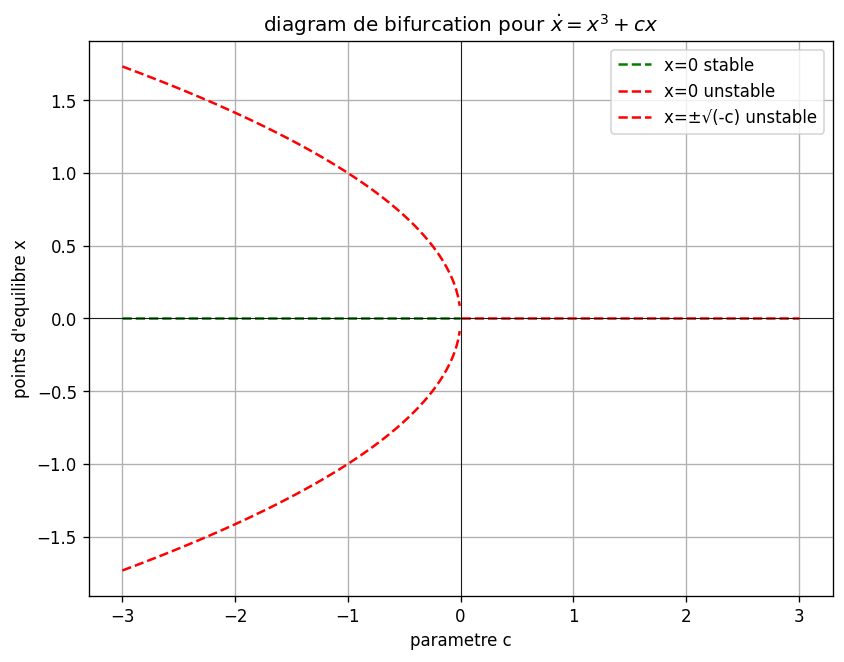

In [9]:
c_vals = np.linspace(-3, 3, 400)

x_0 = np.zeros_like(c_vals)

c_neg = c_vals[c_vals < 0] 
c_pos = c_vals[c_vals >= 0]

x_pos = np.sqrt(-c_neg)
x_neg = -np.sqrt(-c_neg)

plt.figure(figsize=(8, 6))

# x = 0
plt.plot(c_neg, np.zeros_like(c_neg), 'g--', label='x=0 stable')
plt.plot(c_pos, np.zeros_like(c_pos), 'r--', label='x=0 unstable')

# x = ± (-c)^(1/2)
plt.plot(c_neg, x_pos, 'r--', label='x=±√(-c) unstable')
plt.plot(c_neg, x_neg, 'r--')

# Ozdoby wykresu
plt.title("diagram de bifurcation pour $\dot{x} = x^3 + cx$")
plt.xlabel("parametre c")
plt.ylabel("points d'equilibre x")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.show()


## 2)

Refaire la même question avec $f(x)= - x^2 +x -c$.

Réponse:

**points d'equilibre:**
les solutions de cette équation sont :


x1=(1+(1-4c)**1/2) / 2 et x2=(1-(1-4c)**1/2) / 2

les solutions réelles existent seulement si le distriminent est positif et donc si c<=1/4 et donc par rapport a la signe de c:

- si c>1/4 il n'y a pas de points d'équilibre réels.
- si c = 1/4 il y a un point équilibre x=1/2
- si c < 1/4 il y a deux points d'équilibres x1=(1+(1-4c)**1/2) / 2 et x2=(1-(1-4c)**1/2) / 2


**stabilite des points d'equilibre:**
f'(x) = -2x+1
- si f(x)' < 0 stable
- si f(x)' > 0 instable


f'(x1)=-(1-4c)**1/2

f'(x2)=(1-4c)**1/2

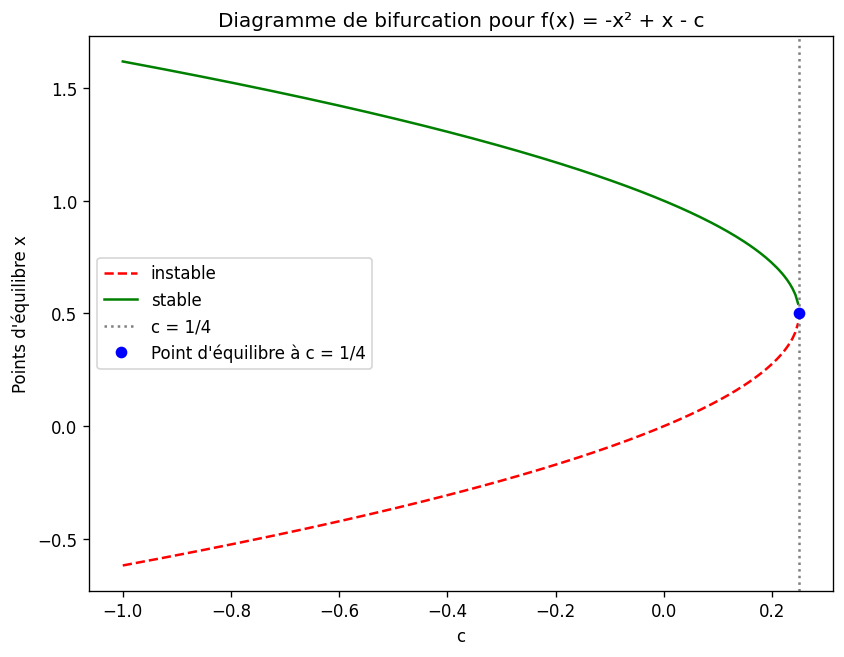

In [10]:
c_vals = np.linspace(-1, 1, 400)
delta = 1 - 4 * c_vals


x_stable = np.full_like(c_vals, np.nan)  
x_unstable = np.full_like(c_vals, np.nan) 


indices_valides = delta >= 0
sqrt_delta = np.sqrt(delta[indices_valides])


x_unstable_vals = (1 - sqrt_delta) / 2  
x_stable_vals = (1 + sqrt_delta) / 2  

x_unstable[indices_valides] = x_unstable_vals
x_stable[indices_valides] = x_stable_vals

plt.figure(figsize=(8, 6))
plt.plot(c_vals[indices_valides], x_unstable[indices_valides], 'r--', label='instable')
plt.plot(c_vals[indices_valides], x_stable[indices_valides], 'g-', label='stable')

plt.axvline(0.25, color='gray', linestyle=':', label='c = 1/4')


plt.plot(0.25, 0.5, 'bo', label='Point d\'équilibre à c = 1/4')

plt.title("Diagramme de bifurcation pour f(x) = -x² + x - c")
plt.xlabel("c")
plt.ylabel("Points d'équilibre x")
plt.legend()
plt.show()


Réponse:

### Exercice 4

On s'interesse ici aux équations de la forme $\ddot{x}(t)+f(x(t))=0$. On rappelle qu'en posant $y(t)=x'(t)$, celle-ci est équivalente au système $\begin{cases}\dot{x}(t)=y(t)\\ \dot{y}(t)=-f(x(t))\end{cases}$. On dit que $x^e$ est un point d'équilibre de l'équation $\ddot{x}(t)+f(x(t))=0$, si $(x^e,0)$ est un point d'équilibre du système associé, c'est-à-dire si $f(x^e)=0$.

On admet le résultat suivant: si $f'(x^e)>0$, alors $(x^e,0)$ est stable. Si au contraire $f'(x^e)<0$, alors $(x^e,0)$ est instable.

## 1)
On considère l'équation du pendule $\ddot{x}(t)+\frac{g}{\ell}\sin(x(t))=0$. Quels sont les points d'équilibre stables ? Instables ?


Réponse: 
Le système associé:

$\begin{cases}\dot{x}(t)=y(t)\\ \dot{y}(t)=-g/l   sin(x(t))\end{cases}$.

On cherche les points où sin(xe)=0 qui veut dire xe=npi (n appartenant à Z)

Donc les points d'équilibres (xe,0) sont (npi,0) pour n appartenant à Z

On trouve la derivé de la fonction donnée : f'(x)=g/lcos(x) et en remplacant x par xe:

f'(xe)=g/lcos(npi)=g/lcos(-1)^n

si n est pair, xe=2kpi et donc stable

si n est impair, xe=(2k+1)pi et donc instable

On suppose maintenant que le point d'attache du pendule est soumis à un mouvement sinusoïde vertical rapide: au temps $t$, la coordonnée verticale de celui-ci est $\epsilon \cos(v t/\epsilon))$ où $v>0$ est une constante homogène à une vitesse, et $\epsilon>0$ est une longueur qui tend vers $0$. On trouvera un exemple d'un tel pendule à https://www.youtube.com/watch?v=GgYABmG_bto.

On peut montrer que quand $\epsilon\to 0$, l'équation vérifiée par l'angle $x(t)$ est

$$\ddot{x}(t)+\frac{1}{\ell}\left(g+\frac{v^2}{2\ell}\cos\left(x(t)\right)\right)\sin(x(t))=0$$

## 2)
Expliquer le phénomène de la vidéo.

Réponse:
Dans la vidéo, on voit l'effet de l'excitation verticale rapide sur le pendule. Lorsque la fréquence du mouvement vertical est en résonance avec le pendule, les oscillations du pendule deviennent de plus en plus amplifiées, créant bifurcation où le pendule passe d'un état stable à un état d'oscillation avec une amplitude de plus en plus grande.
